In [4]:
import os
import json
import pandas as pd
from pathlib import Path
from collections import Counter
from somajo import SoMaJo

In [5]:
# paths
data_paths = [r"results_v0", r"results_v1", r"results_v2",
             "results_llms_v0", "results_llms_v1", "results_llms_v2"]

# init tokenizer
tokenizer = SoMaJo("en_PTB", split_sentences=True)

# vocab dict
vocab = {
    "v0": {"human": Counter(), "model": Counter()},
    "v1": {"human": Counter(), "model": Counter()},
    "v2": {"human": Counter(), "model": Counter()},
    "llms_v0": {"human": Counter(), "model": Counter()},
    "llms_v1": {"human": Counter(), "model": Counter()},
    "llms_v2": {"human": Counter(), "model": Counter()},
}

In [6]:
# loop datasets
for data_path in data_paths:
    path = Path(data_path)
    if not path.is_dir():
        continue

    # load metrics df for this run
    csvfile = path / "raw.csv"
    df = pd.read_csv(csvfile)

    # iterate experiments
    for experiment in os.scandir(path):
        if not experiment.is_dir():
            continue

        current_path = os.path.join(experiment.path, "referencegame")
        if not os.path.isdir(current_path):
            continue

        for game_mode in os.scandir(current_path):
            if not game_mode.is_dir():
                continue

            for episode in os.scandir(game_mode.path):
                if not episode.is_dir():
                    continue

                interaction_file_path = os.path.join(episode.path, "interactions.json")

                try:
                    with open(interaction_file_path, "r") as f:
                        interaction_data = json.load(f)
                except Exception:
                    continue  # skip missing/malformed

                # grab utterance (example: first player turn)
                try:
                    utterance = interaction_data["turns"][0][1]["action"]["content"]
                except Exception:
                    continue

                # tokenize
                sentences = list(tokenizer.tokenize_text([utterance]))
                num_sentences = len(sentences)
                num_tokens = sum(len(s) for s in sentences)

                # update vocab dict
                dataset_key = os.path.basename(data_path).replace("results_", "")
                if dataset_key not in vocab:
                    continue

                # identify describer
                if interaction_file_path.find("human") < interaction_file_path.find("lama"): 
                    speaker = "human"
                else:
                    speaker = "model"
                    
                if "human" not in interaction_file_path:
                    speaker = "model"

                # flatten tokens
                token_texts = [tok.text.lower() for sent in sentences for tok in sent]
                vocab[dataset_key][speaker].update(token_texts)

                # add new metrics to df 
                # find matching row in df
                episode_name_components = episode.path.split("/")
                model_id = episode_name_components[1]
                episode_id = episode_name_components[-1]
                mask = (df["model"] == model_id) & (df["episode"] == episode_id)

                # Build two new rows
                new_rows = pd.DataFrame([
                    {
                        "game": df.loc[mask, "game"].iloc[0],
                        "model": df.loc[mask, "model"].iloc[0],
                        "experiment": df.loc[mask, "experiment"].iloc[0],
                        "episode": df.loc[mask, "episode"].iloc[0],
                        "metric": "SoMaJoTokens",
                        "value": float(num_tokens),
                    },
                    {
                        "game": df.loc[mask, "game"].iloc[0],
                        "model": df.loc[mask, "model"].iloc[0],
                        "experiment": df.loc[mask, "experiment"].iloc[0],
                        "episode": df.loc[mask, "episode"].iloc[0],
                        "metric": "SoMaJoSentences",
                        "value": float(num_sentences),
                    },
                ])
                
                df = pd.concat([df, new_rows], ignore_index=True)

    # save enriched dataframe back
    df.to_csv(path / "raw_enriched.csv", index=False)


   Unnamed: 0           game                                           model  \
0           0  referencegame  05_Meta-Llama-3.1-8B-Instruct-t0.0--human-t0.0   
1           1  referencegame  05_Meta-Llama-3.1-8B-Instruct-t0.0--human-t0.0   
2           2  referencegame  05_Meta-Llama-3.1-8B-Instruct-t0.0--human-t0.0   
3           3  referencegame  05_Meta-Llama-3.1-8B-Instruct-t0.0--human-t0.0   
4           4  referencegame  05_Meta-Llama-3.1-8B-Instruct-t0.0--human-t0.0   

       experiment    episode                                 metric  value  
0  0_letter_grids  episode_4            Generated Expression Length   76.0  
1  0_letter_grids  episode_4  Generated Expression Number of Tokens   15.0  
2  0_letter_grids  episode_4                    Aborted at Player 1    0.0  
3  0_letter_grids  episode_4                    Aborted at Player 2    0.0  
4  0_letter_grids  episode_4                          Request Count    2.0  
   Unnamed: 0           game                             

In [7]:
print(vocab)

{'v0': {'human': Counter({'the': 772, ':': 427, 'expression': 419, 'grid': 356, 'target': 326, 'empty': 233, 'cells': 227, 'in': 161, 'a': 111, "'": 102, 'has': 96, 'are': 95, 'of': 95, 'first': 91, 'is': 87, 'for': 86, 'row': 85, 'x': 83, 'marked': 76, 'only': 76, 'and': 74, 'like': 71, 'cell': 71, 'given': 71, 'within': 68, 'two': 59, 'an': 57, '.': 54, 'last': 54, 'there': 54, 'three': 51, 'column': 51, ',': 49, 'one': 49, 'line': 48, 'look': 45, 'filled': 45, 'with': 41, 'form': 36, 'lines': 32, "'s": 31, 'four': 31, 'middle': 27, 'letter': 26, 'number': 26, 'where': 23, 'all': 22, 'second': 22, '2': 22, 'rows': 21, 'very': 20, 'right': 20, 'square': 20, 'corner': 20, 'five': 19, 'not': 19, 'looks': 19, 'to': 18, 'at': 17, 'symmetrical': 17, 'other': 16, 'no': 16, 'forms': 16, '3': 16, 'big': 16, 'out': 15, 'bottom': 15, 'that': 14, 'by': 13, 'horizontal': 13, 'fully': 13, 'or': 13, '4': 13, 'touch': 12, 'top': 12, 'third': 12, 'xs': 12, 'point': 12, 'squares': 12, 'any': 11, 'exce

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6552 non-null   float64
 1   game        7560 non-null   object 
 2   model       7560 non-null   object 
 3   experiment  7560 non-null   object 
 4   episode     7560 non-null   object 
 5   metric      7560 non-null   object 
 6   value       7560 non-null   float64
dtypes: float64(2), object(5)
memory usage: 413.6+ KB
None


In [9]:
def compute_vocab_growth(vocab):
    records = []
    prev_vocab = {"human": set(), "model": set()}

    # sort versions numerically
    def version_index(key):
        try:
            return int(key.split("_")[-1].replace("v", ""))
        except ValueError:
            return 999

    for round_name in sorted(vocab.keys(), key=version_index):
        round_data = vocab[round_name]

        # determine context: human–model or model–model
        is_model_model = round_name.startswith("llms_")

        # in model–model setting: skip human, only keep model
        speakers = ["model"] if is_model_model else ["human", "model"]

        for speaker in speakers:
            current_vocab = set(round_data.get(speaker, {}).keys())
            prev = prev_vocab.get(speaker, set())

            new_words = current_vocab - prev

            records.append({
                "context": "model–model" if is_model_model else "human–model",
                "round": round_name,
                "speaker": speaker,
                "total_vocab": len(current_vocab),
                "new_words": len(new_words),
            })

            # update only if there was data
            if current_vocab:
                prev_vocab[speaker] = current_vocab

    return pd.DataFrame(records)
vocab_df = compute_vocab_growth(vocab)
print(vocab_df)

       context    round speaker  total_vocab  new_words
0  human–model       v0   human          273        273
1  human–model       v0   model           62         62
2  model–model  llms_v0   model           50          1
3  human–model       v1   human          280        129
4  human–model       v1   model           55         10
5  model–model  llms_v1   model           52          7
6  human–model       v2   human          151         41
7  human–model       v2   model           67         21
8  model–model  llms_v2   model           49          5


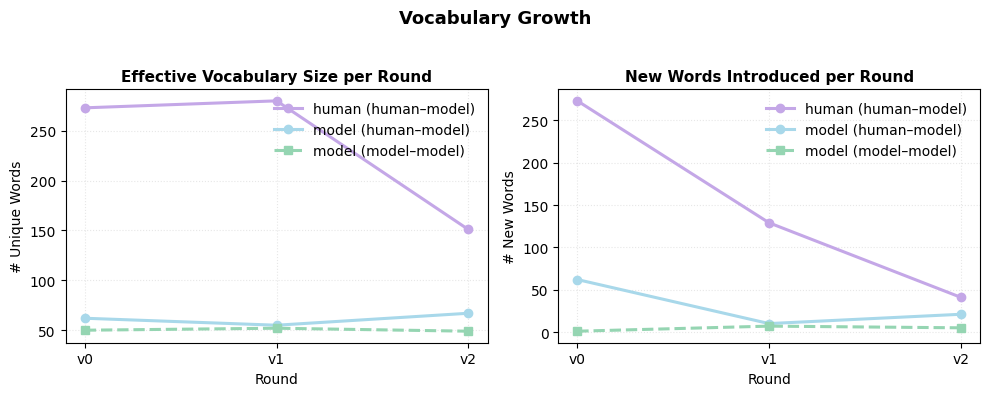

In [10]:
import matplotlib.pyplot as plt

# color palette
colors = {
    "human": "#c4a7e7",        # pastel violet
    "model_hm": "#a8d8ea",     # pastel blue
    "model_mm": "#95d5b2"      # pastel mint green
}

# normalize round names so llms_v* aligns with v*
vocab_df["round_norm"] = vocab_df["round"].str.replace("llms_", "", regex=False)

# prepare subplots: total vocab + new words
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

titles = ["Effective Vocabulary Size per Round", "New Words Introduced per Round"]
x_labels = ["v0", "v1", "v2"]

# filter contexts
hm_df = vocab_df[vocab_df["context"] == "human–model"]
mm_df = vocab_df[vocab_df["context"] == "model–model"]

# left plot: total vocabulary
ax = axes[0]
for speaker, sub in hm_df.groupby("speaker"):
    ax.plot(
        sub["round_norm"], sub["total_vocab"],
        marker="o", linewidth=2.2,
        label=f"{speaker} (human–model)",
        color=colors["human"] if speaker == "human" else colors["model_hm"]
    )

for _, sub in mm_df.groupby("speaker"):
    ax.plot(
        sub["round_norm"], sub["total_vocab"],
        marker="s", linewidth=2.2, linestyle="--",
        label="model (model–model)", color=colors["model_mm"]
    )

ax.set_title(titles[0], fontsize=11, weight="bold")
ax.set_xlabel("Round")
ax.set_ylabel("# Unique Words")
ax.set_xticks(x_labels)
ax.set_xticklabels(x_labels)
ax.grid(alpha=0.3, linestyle=":")
ax.legend(frameon=False, loc="upper right")

# right plot: new words introduced
ax = axes[1]
for speaker, sub in hm_df.groupby("speaker"):
    ax.plot(
        sub["round_norm"], sub["new_words"],
        marker="o", linewidth=2.2,
        label=f"{speaker} (human–model)",
        color=colors["human"] if speaker == "human" else colors["model_hm"]
    )

for _, sub in mm_df.groupby("speaker"):
    ax.plot(
        sub["round_norm"], sub["new_words"],
        marker="s", linewidth=2.2, linestyle="--",
        label="model (model–model)", color=colors["model_mm"]
    )

ax.set_title(titles[1], fontsize=11, weight="bold")
ax.set_xlabel("Round")
ax.set_ylabel("# New Words")
ax.set_xticks(x_labels)
ax.set_xticklabels(x_labels)
ax.grid(alpha=0.3, linestyle=":")
ax.legend(frameon=False, loc="upper right")

# global layout
fig.suptitle("Vocabulary Growth", fontsize=13, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# TTR (Token Type Ration) Lexical diversity normalized by sample size

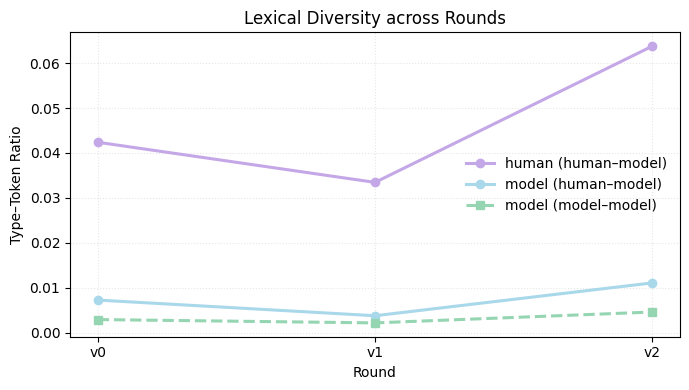

In [29]:
# normalize round names
ttr_df["round_norm"] = ttr_df["round"].str.replace("llms_", "", regex=False)

# split contexts
hm_df = ttr_df[~ttr_df["round"].str.startswith("llms_")]   # human–model
mm_df = ttr_df[ttr_df["round"].str.startswith("llms_")]    # model–model

# X-axis labels
x_labels = ["v0", "v1", "v2"]

# plot setup
plt.figure(figsize=(7, 4))

# human–model lines (human + model)
for spk, sub in hm_df.groupby("speaker"):
    plt.plot(
        sub["round_norm"], sub["ttr"],
        marker="o", linewidth=2.2,
        label=f"{spk} (human–model)",
        color=colors["human"] if spk == "human" else colors["model_hm"]
    )

# add only model–model line (no human line)
mm_model = mm_df[mm_df["speaker"] == "model"]
plt.plot(
    mm_model["round_norm"], mm_model["ttr"],
    marker="s", linewidth=2.2, linestyle="--",
    color=colors["model_mm"],
    label="model (model–model)"
)

plt.xlabel("Round")
plt.ylabel("Type–Token Ratio")
plt.title("Lexical Diversity across Rounds")
plt.xticks(x_labels)
plt.grid(alpha=0.3, linestyle=":")
plt.legend(frameon=False, loc="center right")

plt.tight_layout()
plt.show()


# Compute Overlap and Unique Sets per Round

In [26]:
def compute_vocab_overlap(vocab):
    records = []
    for round_name, speakers in vocab.items():
        human_vocab = set(speakers["human"].keys())
        model_vocab = set(speakers["model"].keys())

        overlap = human_vocab & model_vocab
        human_unique = human_vocab - model_vocab
        model_unique = model_vocab - human_vocab

        records.append({
            "round": round_name,
            "human_vocab_size": len(human_vocab),
            "model_vocab_size": len(model_vocab),
            "shared_vocab_size": len(overlap),
            "human_unique": len(human_unique),
            "model_unique": len(model_unique),
            "overlap_ratio_human": len(overlap) / len(human_vocab) if human_vocab else 0,
            "overlap_ratio_model": len(overlap) / len(model_vocab) if model_vocab else 0,
        })
    return pd.DataFrame(records)

overlap_df = compute_vocab_overlap(vocab)
print(overlap_df)

     round  human_vocab_size  model_vocab_size  shared_vocab_size  \
0       v0               273                62                 54   
1       v1               280                55                 51   
2       v2               151                67                 48   
3  llms_v0                 0                50                  0   
4  llms_v1                 0                52                  0   
5  llms_v2                 0                49                  0   

   human_unique  model_unique  overlap_ratio_human  overlap_ratio_model  
0           219             8             0.197802             0.870968  
1           229             4             0.182143             0.927273  
2           103            19             0.317881             0.716418  
3             0            50             0.000000             0.000000  
4             0            52             0.000000             0.000000  
5             0            49             0.000000             0.000000 

# Look at num Sentence and sentence lengths

In [20]:
import os
import json
import pandas as pd
from pathlib import Path

data_paths = [
    "results_v0", "results_v1", "results_v2",
    "results_llms_v0", "results_llms_v1", "results_llms_v2"
]

# data collector
length_meta = {
    key: {"human": {"num_sentences": [], "num_tokens": []},
          "model": {"num_sentences": [], "num_tokens": []}}
    for key in ["v0", "v1", "v2", "llms_v0", "llms_v1", "llms_v2"]
}

for data_path in data_paths:
    path = Path(data_path)
    if not path.is_dir():
        continue

    print(f"Collecting from {data_path} ...")

    csvfile = path / "raw_enriched.csv"
    if not csvfile.exists():
        print(f"⚠️ Skipping {csvfile} — not found")
        continue

    df = pd.read_csv(csvfile, header=None)
    df.columns = ["idx", "game", "model", "experiment", "episode", "metric", "value"]

    # make value numeric
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])

    dataset_key = os.path.basename(data_path).replace("results_", "")

    # check each episode folder for speaker type
    for experiment in os.scandir(path):
        if not experiment.is_dir():
            continue

        current_path = os.path.join(experiment.path, "referencegame")
        if not os.path.isdir(current_path):
            continue

        for game_mode in os.scandir(current_path):
            if not game_mode.is_dir():
                continue

            for episode in os.scandir(game_mode.path):
                if not episode.is_dir():
                    continue

                interaction_file_path = os.path.join(episode.path, "interactions.json")

                # identify describer 
                if interaction_file_path.find("human") < interaction_file_path.find("lama"): 
                    speaker = "human" 
                else: 
                    speaker = "model" 
                    
                if "human" not in interaction_file_path: speaker = "model"

                # extract episode ID
                episode_id = os.path.basename(episode.path)

                # find matching SoMaJo metrics in CSV
                mask_tokens = (df["episode"] == episode_id) & (df["metric"] == "SoMaJoTokens")
                mask_sentences = (df["episode"] == episode_id) & (df["metric"] == "SoMaJoSentences")
        
                # add values if exist
                if mask_tokens.any():
                    length_meta[dataset_key][speaker]["num_tokens"].extend(df.loc[mask_tokens, "value"].astype(int).tolist())
                if mask_sentences.any():
                    length_meta[dataset_key][speaker]["num_sentences"].extend(df.loc[mask_sentences, "value"].astype(int).tolist())

# summarize averages
summary = []
for dataset_key, speakers in length_meta.items():
    print(dataset_key, speakers)
    for speaker, metrics in speakers.items():
        avg_tokens = sum(metrics["num_tokens"]) / len(metrics["num_tokens"]) if metrics["num_tokens"] else 0
        avg_sentences = sum(metrics["num_sentences"]) / len(metrics["num_sentences"]) if metrics["num_sentences"] else 0
        summary.append({
            "dataset": dataset_key,
            "speaker": speaker,
            "avg_tokens": avg_tokens,
            "avg_sentences": avg_sentences,
            "num_samples": len(metrics["num_tokens"])
        })

summary_df = pd.DataFrame(summary)
print("\n=== Average lengths per dataset/speaker ===")
print(summary_df.to_string(index=False))
summary_df.to_csv("length_summary.csv", index=False)


v0 {'human': {'num_sentences': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [21]:
import numpy as np

for dataset, speakers in length_meta.items():
    for spk in ['human', 'model']:
        toks = np.array(speakers[spk]['num_tokens'])
        if len(toks) > 0:
            print(dataset, spk,
                  "mean:", toks.mean(),
                  "std:", toks.std(),
                  "min:", toks.min(),
                  "max:", toks.max())


v0 human mean: 19.39989059080963 std: 9.35720389637152 min: 1 max: 60
v0 model mean: 19.499302649930264 std: 9.407202917884232 min: 3 max: 60
v1 human mean: 24.148846960167713 std: 14.51338078949696 min: 0 max: 88
v1 model mean: 24.14878459170157 std: 14.512088432520168 min: 0 max: 88
v2 human mean: 16.714285714285715 std: 11.580879933983923 min: 0 max: 47
v2 model mean: 16.714285714285715 std: 11.580879933983923 min: 0 max: 47
llms_v0 model mean: 23.958333333333332 std: 8.753471533562491 min: 14 max: 43
llms_v1 model mean: 23.916666666666668 std: 8.210342393726478 min: 14 max: 43
llms_v2 model mean: 21.25 std: 6.404750840847233 min: 14 max: 39
